# Pokemon Card Price Dataset, SQL Exploration, and Modeling

This notebook is ordered so it can be run from top to bottom. It starts from the raw TCGCSV export in `data/pokemon_card_price_dataset.csv`, creates cleaned and machine-learning-ready CSV files, builds the SQLite database, then runs SQL exploration, visual analysis, and regression modeling.

# Data Cleaning and Feature Engineering

The raw import has one row per product and finish type. This section filters to Pokemon cards, standardizes dates and missing values, and creates derived features used by SQL queries and models.

In [1]:
import pandas as pd
import numpy as np
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

RAW_DATA_PATH = Path("data/pokemon_card_price_dataset.csv")
CLEANED_DATA_PATH = Path("data/pokemon_card_price_cleaned_feature_engineered.csv")
ML_READY_DATA_PATH = Path("data/pokemon_card_price_ml_ready.csv")
DB_PATH = Path("data/pokemon_cards.db")
TABLE_NAME = "pokemon_cards"

if not RAW_DATA_PATH.exists():
    raise FileNotFoundError(
        f"Missing {RAW_DATA_PATH}. Run `python3 import_pokemon_dataset.py` first to create the raw dataset."
    )

df = pd.read_csv(RAW_DATA_PATH)

df["set_release_date"] = pd.to_datetime(df["set_release_date"].astype(str).str[:10], errors="coerce")

df = df[~df["primary_type"].str.lower().str.contains("trainer", na=False)]

excluded = [
    "item",
    "energy",
    "special energy",
    "pokemon tool",
    "stadium",
    "supporter",
    "tool"
]

df = df[~df["primary_type"].str.lower().isin(excluded)]

df["retreat_cost_count"] = df["retreat_cost_count"].fillna(0)
df["has_free_retreat"] = (df["retreat_cost_count"] == 0).astype(int)

df["is_holo_finish"] = df["finish_type"].str.contains("holo", case=False, na=False).astype(int)
df["is_reverse_holo"] = df["finish_type"].str.contains("reverse", case=False, na=False).astype(int)
df["is_first_edition"] = df["finish_type"].str.contains("1st edition", case=False, na=False).astype(int)

rarity_score_map = {
    "Common": 1,
    "Uncommon": 2,
    "Rare": 3,
    "Holo Rare": 4,
    "Promo": 4,
    "Double Rare": 5,
    "Ultra Rare": 6,
    "Illustration Rare": 6,
    "Radiant Rare": 6,
    "Shiny Rare": 6,
    "Secret Rare": 7,
    "Shiny Holo Rare": 7,
    "Special Illustration Rare": 8,
    "Hyper Rare": 8,
    "Rainbow Rare": 8,
}
df["rarity_score"] = df["rarity"].map(rarity_score_map).fillna(5)

subtype_stage_map = {
    "Basic": 0,
    "Baby": 0,
    "Stage 1": 1,
    "Restored": 1,
    "Stage 2": 2,
    "BREAK Evolution": 2,
    "Level Up": 2,
    "Level-Up": 2,
    "Mega": 3,
    "Mega Evolution": 3,
    "MEGA": 3,
    "VSTAR": 3,
    "VMAX": 3,
    "Gigantamax": 3,
    "V-UNION": 3,
    "V-Union": 3,
    "Legend": 3,
    "LEGEND": 3,
    "Primal": 3,
}
df["evolution_stage_score"] = df["primary_subtype"].map(subtype_stage_map).fillna(0)

df["release_year"] = df["set_release_date"].dt.year
df["card_position_ratio"] = (df["card_number_numeric"] / df["set_total"]).replace([float("inf"), -float("inf")], 0).fillna(0)
df["is_numbered_above_set_total"] = (df["card_number_numeric"] > df["set_total"]).astype(int)
df["hp_per_attack"] = (df["hp"] / df["attack_count"].where(df["attack_count"] != 0)).fillna(0)
df["retreat_per_hp"] = (df["retreat_cost_count"] / df["hp"].where(df["hp"] != 0)).fillna(0)

df = df.drop(columns=["product_url"], errors="ignore")
CLEANED_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(CLEANED_DATA_PATH, index=False)

ml_df = df.copy()
ml_df["log_price"] = np.log1p(ml_df["market_price_usd"])
ml_df["set_release_date_ordinal"] = ml_df["set_release_date"].map(pd.Timestamp.toordinal)

categorical_cols = ["finish_type", "rarity", "primary_type", "primary_subtype"]
drop_cols = ["card_id", "card_name", "set_id", "set_name", "set_release_date"]
ml_df = ml_df.drop(columns=drop_cols)

numeric_cols = ml_df.select_dtypes(include=["number"]).columns
ml_df[numeric_cols] = ml_df[numeric_cols].fillna(0)
ml_df = pd.get_dummies(ml_df, columns=categorical_cols, dummy_na=False, dtype=int)
ml_df.to_csv(ML_READY_DATA_PATH, index=False)

print(f"Raw rows: {pd.read_csv(RAW_DATA_PATH).shape[0]:,}")
print(f"Cleaned rows: {len(df):,}")
print(f"Saved cleaned data to {CLEANED_DATA_PATH}")
print(f"Saved ML-ready data to {ML_READY_DATA_PATH}")
df.head()

Raw rows: 33,112
Cleaned rows: 32,433
Saved cleaned data to data/pokemon_card_price_cleaned_feature_engineered.csv
Saved ML-ready data to data/pokemon_card_price_ml_ready.csv


,card_id,card_name,set_id,set_name,set_release_date,market_price_usd,finish_type,rarity,hp,primary_type,...,is_holo_finish,is_reverse_holo,is_first_edition,rarity_score,evolution_stage_score,release_year,card_position_ratio,is_numbered_above_set_total,hp_per_attack,retreat_per_hp
0,42386,Abra,604,Base Set,1999-01-09,1.06,Normal,Common,30.0,Psychic,...,0,0,0,1.0,0.0,1999,0.421569,0,30.0,0.0000
1,42346,Alakazam,604,Base Set,1999-01-09,68.55,Holofoil,Holo Rare,80.0,Psychic,...,1,0,0,4.0,2.0,1999,0.009804,0,80.0,0.0375
2,42364,Arcanine,604,Base Set,1999-01-09,3.84,Normal,Uncommon,100.0,Fire,...,0,0,0,2.0,2.0,1999,0.225490,0,50.0,0.0300
3,42357,Beedrill,604,Base Set,1999-01-09,7.37,Normal,Rare,80.0,Grass,...,0,0,0,3.0,2.0,1999,0.166667,0,40.0,0.0000
4,42360,Blastoise,604,Base Set,1999-01-09,213.81,Holofoil,Holo Rare,100.0,Water,...,1,0,0,4.0,2.0,1999,0.019608,0,100.0,0.0300


# Database Setup and SQL Exploration

After creating the cleaned feature-engineered dataset, this section loads it into a local SQLite database. This makes it easier to answer distribution questions with SQL queries.

In [2]:
import sqlite3

cards_db_df = pd.read_csv(CLEANED_DATA_PATH)
cards_db_df["set_release_date"] = pd.to_datetime(cards_db_df["set_release_date"]).dt.strftime("%Y-%m-%d")

DB_PATH.parent.mkdir(parents=True, exist_ok=True)
with sqlite3.connect(DB_PATH) as conn:
    cards_db_df.to_sql(TABLE_NAME, conn, if_exists="replace", index=False)
    conn.execute("CREATE INDEX IF NOT EXISTS idx_cards_price ON pokemon_cards(market_price_usd)")
    conn.execute("CREATE INDEX IF NOT EXISTS idx_cards_type ON pokemon_cards(primary_type)")
    conn.execute("CREATE INDEX IF NOT EXISTS idx_cards_year ON pokemon_cards(release_year)")
    conn.execute("CREATE INDEX IF NOT EXISTS idx_cards_set ON pokemon_cards(set_name)")

def sql_query(query):
    with sqlite3.connect(DB_PATH) as conn:
        return pd.read_sql_query(query, conn)

print(f"Created SQLite database at {DB_PATH} with {len(cards_db_df):,} rows in table '{TABLE_NAME}'.")
cards_db_df.head()

Created SQLite database at data/pokemon_cards.db with 32,433 rows in table 'pokemon_cards'.


,card_id,card_name,set_id,set_name,set_release_date,market_price_usd,finish_type,rarity,hp,primary_type,...,is_holo_finish,is_reverse_holo,is_first_edition,rarity_score,evolution_stage_score,release_year,card_position_ratio,is_numbered_above_set_total,hp_per_attack,retreat_per_hp
0,42386,Abra,604,Base Set,1999-01-09,1.06,Normal,Common,30.0,Psychic,...,0,0,0,1.0,0.0,1999,0.421569,0,30.0,0.0000
1,42346,Alakazam,604,Base Set,1999-01-09,68.55,Holofoil,Holo Rare,80.0,Psychic,...,1,0,0,4.0,2.0,1999,0.009804,0,80.0,0.0375
2,42364,Arcanine,604,Base Set,1999-01-09,3.84,Normal,Uncommon,100.0,Fire,...,0,0,0,2.0,2.0,1999,0.225490,0,50.0,0.0300
3,42357,Beedrill,604,Base Set,1999-01-09,7.37,Normal,Rare,80.0,Grass,...,0,0,0,3.0,2.0,1999,0.166667,0,40.0,0.0000
4,42360,Blastoise,604,Base Set,1999-01-09,213.81,Holofoil,Holo Rare,100.0,Water,...,1,0,0,4.0,2.0,1999,0.019608,0,100.0,0.0300


## Query 1: How many cards are in each price range?

This shows how skewed the card market is by counting cards in practical dollar buckets.

In [3]:
price_range_query = """
SELECT
    CASE
        WHEN market_price_usd < 1 THEN '$0-$1'
        WHEN market_price_usd < 5 THEN '$1-$5'
        WHEN market_price_usd < 10 THEN '$5-$10'
        WHEN market_price_usd < 25 THEN '$10-$25'
        WHEN market_price_usd < 50 THEN '$25-$50'
        WHEN market_price_usd < 100 THEN '$50-$100'
        ELSE '$100+'
    END AS price_range,
    COUNT(*) AS card_count,
    ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM pokemon_cards), 2) AS percent_of_cards,
    ROUND(AVG(market_price_usd), 2) AS avg_price_usd
FROM pokemon_cards
GROUP BY
    CASE
        WHEN market_price_usd < 1 THEN 1
        WHEN market_price_usd < 5 THEN 2
        WHEN market_price_usd < 10 THEN 3
        WHEN market_price_usd < 25 THEN 4
        WHEN market_price_usd < 50 THEN 5
        WHEN market_price_usd < 100 THEN 6
        ELSE 7
    END
ORDER BY MIN(market_price_usd);
"""
sql_query(price_range_query)

,price_range,card_count,percent_of_cards,avg_price_usd
0,$0-$1,16476,50.80,0.33
1,$1-$5,6403,19.74,2.44
2,$5-$10,2652,8.18,7.17
3,$10-$25,2930,9.03,16.15
4,$25-$50,1716,5.29,35.25
5,$50-$100,1132,3.49,70.90
6,$100+,1124,3.47,285.61


### Thoughts:

Most cards are low-priced: about 50.8% of the dataset is under $1, and roughly 70.5% is under $5. The $100+ group is only about 3.5% of the cards, but its average price is much higher, which shows that a small number of expensive cards heavily skew the overall price distribution. This is a strong query because it explains why later analysis should use medians, log prices, or price bands instead of relying only on raw average price.

## Query 2: What is the average card price for each pack/set?

The dataset has cards and sets rather than sealed pack prices, so set name is used as the pack/set grouping.

In [4]:
avg_pack_price_query = """
SELECT
    set_name AS pack_or_set,
    release_year,
    COUNT(*) AS card_count,
    ROUND(AVG(market_price_usd), 2) AS avg_price_usd,
    ROUND(MIN(market_price_usd), 2) AS min_price_usd,
    ROUND(MAX(market_price_usd), 2) AS max_price_usd
FROM pokemon_cards
GROUP BY set_name, release_year
HAVING COUNT(*) >= 20
ORDER BY avg_price_usd DESC
LIMIT 15;
"""
sql_query(avg_pack_price_query)

,pack_or_set,release_year,card_count,avg_price_usd,min_price_usd,max_price_usd
0,Base Set (Shadowless),1999,135,182.39,1.50,10000.00
1,Neo Destiny,2002,185,105.11,0.52,4249.99
2,Legendary Collection,2002,186,96.86,0.43,2100.00
3,Skyridge,2003,234,91.65,3.59,1249.94
4,POP Series 4,2026,20,73.74,1.22,605.26
5,Delta Species,2005,180,72.28,0.44,2100.98
6,WoTC Promo,1999,64,70.34,6.05,999.95
7,Aquapolis,2003,265,68.82,1.48,2225.00
8,Dragon Frontiers,2006,154,68.66,0.32,4000.00
9,Holon Phantoms,2006,172,66.14,0.24,3200.00


### Thoughts:

Older collector-focused sets dominate the top average prices, especially Base Set (Shadowless), Neo Destiny, Legendary Collection, and Skyridge. This is useful because it shows that set identity and release era matter a lot. However, this is not a perfect query for pack prices because the dataset contains individual card prices, not sealed booster pack prices, so this should be interpreted as average card price by set rather than true pack value.

## Query 3: What is the average price of each Pokemon type?

This compares Pokemon card types while keeping enough rows in each group to avoid tiny categories dominating the answer.

In [5]:
avg_type_price_query = """
SELECT
    primary_type,
    COUNT(*) AS card_count,
    ROUND(AVG(market_price_usd), 2) AS avg_price_usd,
    ROUND(MIN(market_price_usd), 2) AS min_price_usd,
    ROUND(MAX(market_price_usd), 2) AS max_price_usd
FROM pokemon_cards
GROUP BY primary_type
HAVING COUNT(*) >= 50
ORDER BY avg_price_usd DESC;
"""
sql_query(avg_type_price_query)

,primary_type,card_count,avg_price_usd,min_price_usd,max_price_usd
0,Fire,2947,29.60,0.02,10000.00
1,Darkness,2132,22.73,0.02,4249.99
2,Dragon,907,22.62,0.03,2495.66
3,Lightning,2826,19.70,0.02,3200.00
4,Water,4623,17.38,0.02,2100.98
5,Psychic,4415,17.12,0.02,1400.28
6,Colorless,4110,15.97,0.02,2225.00
7,Metal,1669,10.86,0.02,1562.48
8,Fairy,430,10.27,0.13,546.71
9,Grass,4486,9.95,0.02,950.00


### Thoughts:

Fire has the highest average price in this grouping, followed by Darkness and Dragon. This likely reflects expensive iconic cards and collector demand rather than the card type itself causing higher prices. This query is helpful for a broad comparison, but it may not be the best standalone predictor because type can be confounded by famous Pokemon, rarity, set age, and finish type.

## Query 4: How do card counts and prices change by release year?

Grouping by release year helps show how much data exists for each era and whether older or newer years have higher average prices.

In [6]:
year_distribution_query = """
SELECT
    release_year,
    COUNT(*) AS card_count,
    ROUND(AVG(market_price_usd), 2) AS avg_price_usd,
    ROUND(MIN(market_price_usd), 2) AS min_price_usd,
    ROUND(MAX(market_price_usd), 2) AS max_price_usd
FROM pokemon_cards
GROUP BY release_year
ORDER BY release_year;
"""
sql_query(year_distribution_query)

,release_year,card_count,avg_price_usd,min_price_usd,max_price_usd
0,1999,507,74.52,0.38,10000.00
1,2000,770,29.98,0.37,1299.96
2,2001,274,40.01,0.46,532.81
3,2002,651,85.91,0.43,4249.99
4,2003,1016,50.06,0.33,2225.00
5,2004,738,42.36,0.20,1999.99
6,2005,735,51.00,0.31,2100.98
7,2006,631,55.70,0.24,4000.00
8,2007,891,16.26,0.17,1701.21
9,2008,808,13.54,0.15,600.00


### Thoughts:

The highest average prices appear in older years such as 1999, 2002, and 2006, which supports the idea that age and nostalgia are important in card value. The yearly card counts also show that the dataset is not evenly distributed across years. This is a strong query for understanding time trends, but averages can still be distorted by one or two extremely expensive cards in a year.

## Query 5: Which finish types have the highest average price?

This query compares normal, holofoil, reverse holofoil, first edition, and unlimited finishes to see which finish styles are most valuable on average.

In [7]:
finish_type_query = """
SELECT
    finish_type,
    COUNT(*) AS card_count,
    ROUND(AVG(market_price_usd), 2) AS avg_price_usd,
    ROUND(MAX(market_price_usd), 2) AS max_price_usd
FROM pokemon_cards
GROUP BY finish_type
ORDER BY avg_price_usd DESC;
"""
sql_query(finish_type_query)

,finish_type,card_count,avg_price_usd,max_price_usd
0,1st Edition Holofoil,148,288.70,10000.00
1,Unlimited Holofoil,165,160.96,3998.99
2,Holofoil,8674,34.51,4000.00
3,1st Edition,588,17.45,359.95
4,Reverse Holofoil,10982,10.91,2100.00
5,Unlimited,589,5.55,144.78
6,Normal,11287,4.19,1999.99


### Thoughts:

Finish type shows a clear price difference: 1st Edition Holofoil and Unlimited Holofoil have much higher average prices than Normal cards. This is one of the stronger SQL queries because finish type directly represents collector-relevant card versions, and the result supports the idea that visual/card edition features matter more than gameplay stats.

## Query 6: Which rarities have the highest average price?

This query groups cards by rarity and filters out very small rarity groups so the comparison is more stable.

In [8]:
rarity_price_query = """
SELECT
    rarity,
    COUNT(*) AS card_count,
    ROUND(AVG(market_price_usd), 2) AS avg_price_usd,
    ROUND(MAX(market_price_usd), 2) AS max_price_usd
FROM pokemon_cards
GROUP BY rarity
HAVING COUNT(*) >= 20
ORDER BY avg_price_usd DESC;
"""
sql_query(rarity_price_query)

,rarity,card_count,avg_price_usd,max_price_usd
0,Secret Rare,357,138.78,4249.99
1,Special Illustration Rare,149,126.87,1475.53
2,Rainbow Rare,36,61.18,482.72
3,Ultra Rare,2073,58.21,4000.00
4,Holo Rare,3201,43.33,10000.00
5,Shiny Holo Rare,235,35.38,598.90
6,Promo,2895,27.13,1999.99
7,Radiant Rare,31,24.41,184.64
8,Illustration Rare,477,17.40,376.96
9,Hyper Rare,40,15.48,78.90


### Thoughts:

Secret Rare and Special Illustration Rare cards have the highest average prices among rarity groups with enough rows. This is a strong query because rarity is directly related to scarcity and collector value. One limitation is that rarity names changed across Pokemon eras, so some rarity categories may not be perfectly comparable across every release year.

## Query 7: Are secret rare cards more expensive than non-secret rare cards?

This query compares secret rare cards against all other cards using card count, average price, and maximum price.

In [9]:
secret_rare_query = """
SELECT
    CASE WHEN is_secret_rare = 1 THEN 'Secret rare' ELSE 'Not secret rare' END AS secret_rare_group,
    COUNT(*) AS card_count,
    ROUND(AVG(market_price_usd), 2) AS avg_price_usd,
    ROUND(MAX(market_price_usd), 2) AS max_price_usd
FROM pokemon_cards
GROUP BY is_secret_rare
ORDER BY avg_price_usd DESC;
"""
sql_query(secret_rare_query)

,secret_rare_group,card_count,avg_price_usd,max_price_usd
0,Secret rare,1386,61.36,4249.99
1,Not secret rare,31047,14.95,10000.00


### Thoughts:

Secret rare cards have a much higher average price than non-secret rare cards, which supports the idea that cards numbered above the set total tend to be more valuable. This is a useful query because it turns a feature-engineered column into an interpretable comparison. However, the maximum non-secret rare price is still higher because some iconic older cards, such as early Charizard cards, are extremely valuable even without being marked as secret rare.

## Query 8: What is the most expensive card from each release year?

This query ranks cards within each release year and returns the highest-priced card for every year in the dataset.

In [10]:
top_cards_by_year_query = """
WITH ranked_cards AS (
    SELECT
        release_year,
        card_name,
        set_name,
        rarity,
        finish_type,
        market_price_usd,
        ROW_NUMBER() OVER (
            PARTITION BY release_year
            ORDER BY market_price_usd DESC
        ) AS price_rank
    FROM pokemon_cards
)
SELECT
    release_year,
    card_name,
    set_name,
    rarity,
    finish_type,
    market_price_usd
FROM ranked_cards
WHERE price_rank = 1
ORDER BY release_year;
"""
sql_query(top_cards_by_year_query)

,release_year,card_name,set_name,rarity,finish_type,market_price_usd
0,1999,Charizard,Base Set (Shadowless),Holo Rare,1st Edition Holofoil,10000.00
1,2000,Lugia,Neo Genesis,Holo Rare,1st Edition Holofoil,1299.96
2,2001,Shining Gyarados,Neo Revelation,Secret Rare,Unlimited Holofoil,532.81
3,2002,Shining Tyranitar,Neo Destiny,Secret Rare,1st Edition Holofoil,4249.99
4,2003,Lugia,Aquapolis,Secret Rare,Holofoil,2225.00
5,2004,Pikachu - 5/5,Kids WB Promos,Promo,Normal,1999.99
6,2005,Kyogre Star,Delta Species,Ultra Rare,Holofoil,2100.98
7,2006,Charizard Star (Delta Species),Dragon Frontiers,Ultra Rare,Holofoil,4000.00
8,2007,Jolteon Star,Power Keepers,Ultra Rare,Holofoil,1701.21
9,2008,Charizard,Stormfront,Secret Rare,Holofoil,600.00


### Thoughts:

The most expensive card in each year is often a famous card, rare finish, or older collector chase card. This query is good for finding examples and telling a story, but it is not the best distribution query because it only looks at one card per year and ignores the rest of the cards. It is best used as a highlight table rather than evidence for the average card in each year.

# Data Exploration:

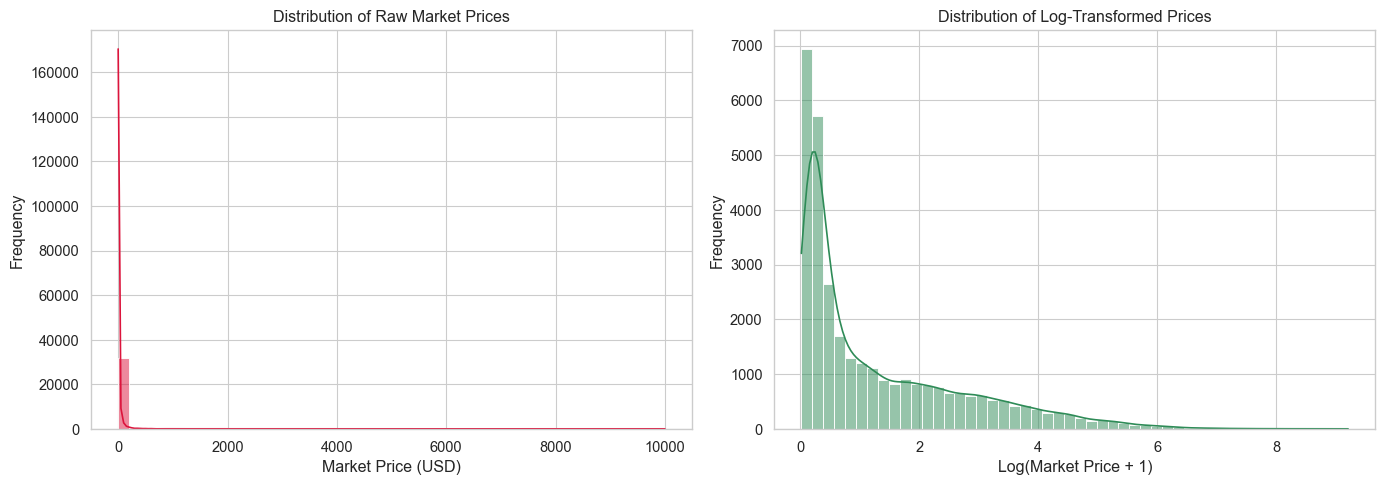

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['market_price_usd'], bins=50, kde=True, ax=axes[0], color='crimson')
axes[0].set_title('Distribution of Raw Market Prices')
axes[0].set_xlabel('Market Price (USD)')
axes[0].set_ylabel('Frequency')

log_prices = np.log1p(df['market_price_usd'])
sns.histplot(log_prices, bins=50, kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('Distribution of Log-Transformed Prices')
axes[1].set_xlabel('Log(Market Price + 1)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [12]:
top_10_expensive = df.nlargest(10, 'market_price_usd')[
    ['card_name', 'set_name', 'rarity', 'finish_type', 'market_price_usd']
]
print("Top 10 Most Expensive Cards:")
print(top_10_expensive.to_string(index=False))
print("\n")

top_10_cheapest = df.nsmallest(10, 'market_price_usd')[
    ['card_name', 'set_name', 'rarity', 'finish_type', 'market_price_usd']
]
print("Top 10 Cheapest Cards:")
print(top_10_cheapest.to_string(index=False))
print("\n")

Top 10 Most Expensive Cards:
                              card_name              set_name      rarity          finish_type  market_price_usd
                              Charizard Base Set (Shadowless)   Holo Rare 1st Edition Holofoil          10000.00
                      Shining Tyranitar           Neo Destiny Secret Rare 1st Edition Holofoil           4249.99
         Charizard Star (Delta Species)      Dragon Frontiers  Ultra Rare             Holofoil           4000.00
                      Shining Charizard           Neo Destiny Secret Rare   Unlimited Holofoil           3998.99
                           Pikachu Star        Holon Phantoms  Ultra Rare             Holofoil           3200.00
Latias & Latios GX (Alternate Full Art)          SM - Team Up  Ultra Rare             Holofoil           2495.66
                                  Lugia             Aquapolis Secret Rare             Holofoil           2225.00
                              Charizard Base Set (Shadowless)   Hol

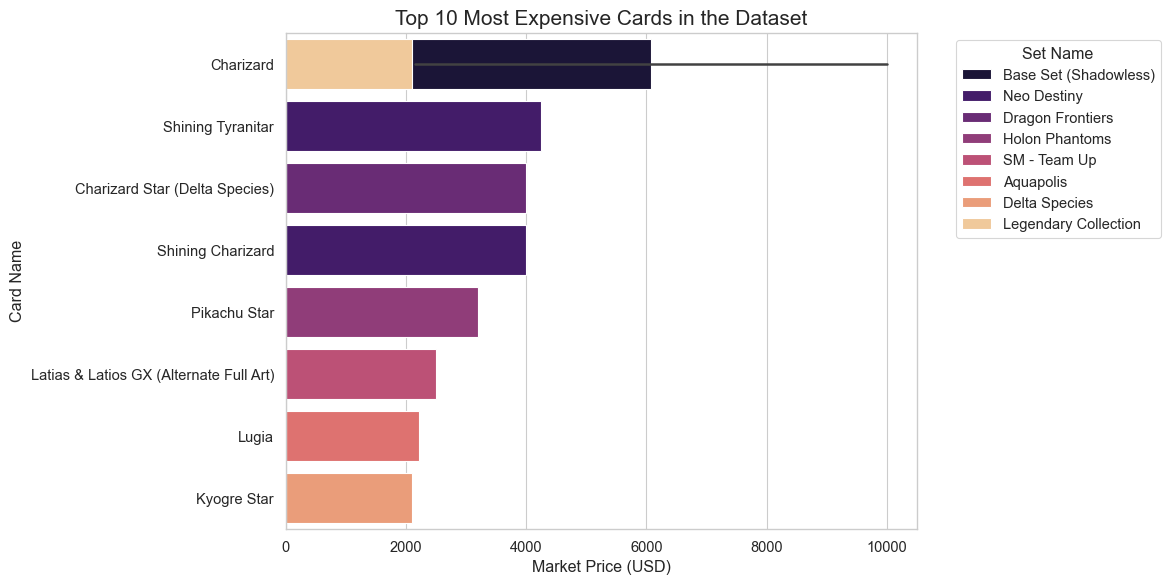

In [13]:
plt.figure(figsize=(12, 6))
top_10_df = df.nlargest(10, 'market_price_usd')
sns.barplot(
    data=top_10_df, 
    x='market_price_usd', 
    y='card_name', 
    hue='set_name', 
    dodge=False,
    palette='magma'
)

plt.title('Top 10 Most Expensive Cards in the Dataset', fontsize=15)
plt.xlabel('Market Price (USD)')
plt.ylabel('Card Name')
plt.legend(title='Set Name', bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.tight_layout()
plt.show()

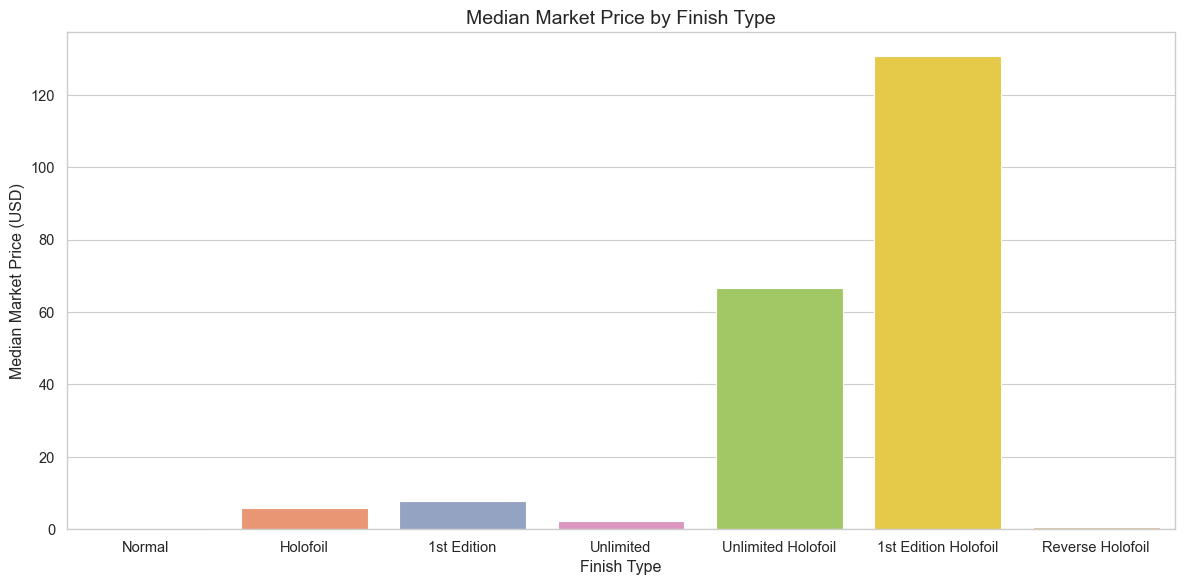

In [14]:
plt.figure(figsize=(12, 6))
                                                                                  
sns.barplot(
    data=df, 
    x='finish_type', 
    y='market_price_usd', 
    estimator='median', 
    errorbar=None, 
    palette='Set2'
)

plt.title('Median Market Price by Finish Type', fontsize=14)
plt.xlabel('Finish Type')
plt.ylabel('Median Market Price (USD)')
plt.tight_layout()
plt.show()

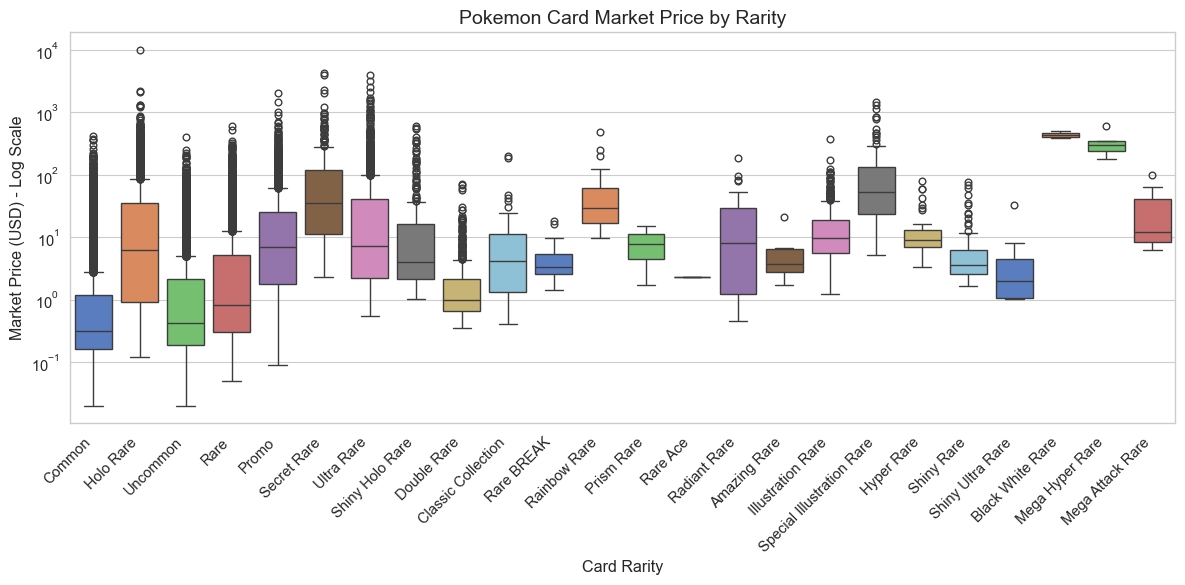

In [15]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='rarity', y='market_price_usd', palette='muted')

plt.title('Pokemon Card Market Price by Rarity', fontsize=14)
plt.xlabel('Card Rarity')
plt.ylabel('Market Price (USD) - Log Scale')
plt.yscale('log')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

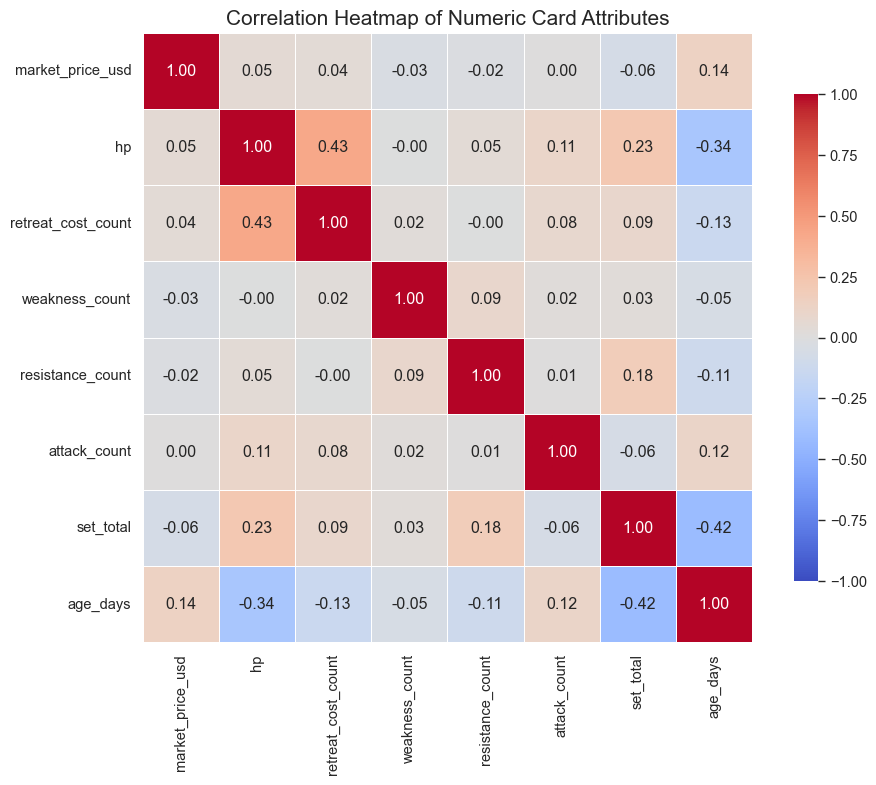

In [16]:
plt.figure(figsize=(10, 8))

numeric_cols = [
    'market_price_usd', 'hp', 'retreat_cost_count', 'weakness_count', 
    'resistance_count', 'attack_count', 'set_total', 'age_days'
]
corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, 
            square=True, linewidths=.5, cbar_kws={"shrink": .8})

plt.title('Correlation Heatmap of Numeric Card Attributes', fontsize=15)
plt.tight_layout()
plt.show()

# Machine Learning:

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

model_df = df.dropna(subset=['market_price_usd']).copy()
model_df['log_price'] = np.log1p(model_df['market_price_usd'])

threshold_age = model_df['age_days'].quantile(0.10)
train_df = model_df[model_df['age_days'] > threshold_age]
test_df = model_df[model_df['age_days'] <= threshold_age]

feature_cols = [
    'finish_type', 'rarity', 'hp', 'primary_type', 'primary_subtype', 
    'retreat_cost_count', 'has_free_retreat', 'weakness_count', 
    'resistance_count', 'attack_count', 'avg_attack_cost_length', 'set_total', 
    'age_days', 'release_year', 'card_number_numeric', 'card_position_ratio', 
    'is_secret_rare', 'is_numbered_above_set_total', 'is_holo_finish', 
    'is_reverse_holo', 'is_first_edition', 'rarity_score', 
    'evolution_stage_score', 'hp_per_attack', 'retreat_per_hp'
]

X_train = train_df[feature_cols]
y_train = train_df['log_price']

X_test = test_df[feature_cols]
y_test = test_df['log_price']
y_test_actual = np.expm1(y_test)
y_train_actual = train_df['market_price_usd']

categorical_features = ['finish_type', 'rarity', 'primary_type', 'primary_subtype']
numeric_features = [
    'hp', 'retreat_cost_count', 'has_free_retreat', 'weakness_count', 
    'resistance_count', 'attack_count', 'avg_attack_cost_length', 'set_total', 
    'age_days', 'release_year', 'card_number_numeric', 'card_position_ratio', 
    'is_secret_rare', 'is_numbered_above_set_total', 'is_holo_finish', 
    'is_reverse_holo', 'is_first_edition', 'rarity_score', 
    'evolution_stage_score', 'hp_per_attack', 'retreat_per_hp'
]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0.0)),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

linear_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0))
])

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

def summarize_predictions(name, y_actual, y_pred_actual):
    mae = mean_absolute_error(y_actual, y_pred_actual)
    rmse = np.sqrt(mean_squared_error(y_actual, y_pred_actual))
    r2 = r2_score(y_actual, y_pred_actual)
    return {
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
    }

def evaluate_model(name, pipeline, X_test, y_test_log, y_test_actual):
    y_pred_log = pipeline.predict(X_test)
    y_pred_actual = np.maximum(np.expm1(y_pred_log), 0)
    metrics = summarize_predictions(name, y_test_actual, y_pred_actual)
    print(f"--- {name} Performance ---")
    print(f"MAE:  ${metrics['MAE']:.2f}")
    print(f"RMSE: ${metrics['RMSE']:.2f}")
    print(f"R^2:  {metrics['R2']:.4f}\n")
    return metrics

overall_median_pred = np.full(len(y_test_actual), y_train_actual.median())
rarity_finish_medians = train_df.groupby(['rarity', 'finish_type'])['market_price_usd'].median()
rarity_medians = train_df.groupby('rarity')['market_price_usd'].median()
global_median = y_train_actual.median()

def lookup_group_median(row):
    key = (row['rarity'], row['finish_type'])
    if key in rarity_finish_medians.index:
        return rarity_finish_medians.loc[key]
    if row['rarity'] in rarity_medians.index:
        return rarity_medians.loc[row['rarity']]
    return global_median

group_median_pred = test_df.apply(lookup_group_median, axis=1).to_numpy()

baseline_metrics = [
    summarize_predictions('Baseline: overall train median', y_test_actual, overall_median_pred),
    summarize_predictions('Baseline: rarity + finish median', y_test_actual, group_median_pred),
]

print("Training Linear (Ridge) Model...")
linear_pipeline.fit(X_train, y_train)

print("Training Random Forest Model...")
rf_pipeline.fit(X_train, y_train)

model_metrics = baseline_metrics + [
    evaluate_model("Linear Regression (Ridge)", linear_pipeline, X_test, y_test, y_test_actual),
    evaluate_model("Random Forest", rf_pipeline, X_test, y_test, y_test_actual),
]

metrics_df = pd.DataFrame(model_metrics)
display(metrics_df.style.format({'MAE': '${:.2f}', 'RMSE': '${:.2f}', 'R2': '{:.4f}'}))

Training Linear (Ridge) Model...
Training Random Forest Model...


--- Linear Regression (Ridge) Performance ---
MAE:  $11.73
RMSE: $51.85
R^2:  0.0306

--- Random Forest Performance ---
MAE:  $11.74
RMSE: $51.27
R^2:  0.0521



,Model,MAE,RMSE,R2
0,Baseline: overall train median,$12.88,$54.02,-0.0523
1,Baseline: rarity + finish median,$11.65,$51.85,0.0308
2,Linear Regression (Ridge),$11.73,$51.85,0.0306
3,Random Forest,$11.74,$51.27,0.0521


# Analysis:

The baseline rows give the regression models a practical reference point. The overall median baseline is intentionally simple, while the rarity-plus-finish baseline tests how far we can get using two collector-relevant categories.

The model MAE should be interpreted against the highly skewed price distribution: an error around several dollars can be acceptable for expensive cards, but it is large for the many cards priced under $5. RMSE is much larger than MAE because a small number of expensive chase cards create very large misses.

The low R^2 means the models explain only a small share of the variance in actual dollar prices. This supports one of the main findings of the project: structured card attributes such as HP, attack count, retreat cost, type, rarity, and finish help describe the market, but they do not fully capture collector demand.

A likely reason is that Pokemon card prices are driven by factors not present in the dataset, including Pokemon popularity, artwork, nostalgia, competitive metagame history, condition, grading status, seller behavior, and recent sales volume.


# Cross Validation:

To make the model evaluation more reliable, we also use time-based cross validation. Since Pokemon card prices are connected to release date and card age, we sort the data by release date and use each fold to train on older cards and validate on newer cards.

In [18]:
from sklearn.base import clone
from sklearn.model_selection import TimeSeriesSplit

cv_df = model_df.sort_values('set_release_date').reset_index(drop=True)
X_cv = cv_df[feature_cols]
y_cv = cv_df['log_price']
y_cv_actual = np.expm1(y_cv)

time_cv = TimeSeriesSplit(n_splits=5)

def cross_validate_price_model(name, pipeline):
    fold_results = []
    
    for fold, (train_idx, val_idx) in enumerate(time_cv.split(X_cv), start=1):
        model = clone(pipeline)
        model.fit(X_cv.iloc[train_idx], y_cv.iloc[train_idx])
        
        y_pred_log = model.predict(X_cv.iloc[val_idx])
        y_pred_actual = np.expm1(y_pred_log)
        y_val_actual = y_cv_actual.iloc[val_idx]
        
        fold_results.append({
            'Fold': fold,
            'Train Rows': len(train_idx),
            'Validation Rows': len(val_idx),
            'MAE': mean_absolute_error(y_val_actual, y_pred_actual),
            'RMSE': np.sqrt(mean_squared_error(y_val_actual, y_pred_actual)),
            'R2': r2_score(y_val_actual, y_pred_actual)
        })
    
    results_df = pd.DataFrame(fold_results)
    print(f'--- {name} Time-Based Cross Validation ---')
    print(results_df.to_string(index=False, formatters={
        'MAE': '${:.2f}'.format,
        'RMSE': '${:.2f}'.format,
        'R2': '{:.4f}'.format
    }))
    print(f"Average MAE:  ${results_df['MAE'].mean():.2f}")
    print(f"Average RMSE: ${results_df['RMSE'].mean():.2f}")
    print(f"Average R^2:  {results_df['R2'].mean():.4f}\n")
    return results_df

linear_cv_results = cross_validate_price_model('Linear Regression (Ridge)', linear_pipeline)
rf_cv_results = cross_validate_price_model('Random Forest', rf_pipeline)

cv_summary = pd.DataFrame({
    'Model': ['Linear Regression (Ridge)', 'Random Forest'],
    'Average MAE': [linear_cv_results['MAE'].mean(), rf_cv_results['MAE'].mean()],
    'Average RMSE': [linear_cv_results['RMSE'].mean(), rf_cv_results['RMSE'].mean()],
    'Average R2': [linear_cv_results['R2'].mean(), rf_cv_results['R2'].mean()]
})

cv_summary

--- Linear Regression (Ridge) Time-Based Cross Validation ---
 Fold  Train Rows  Validation Rows    MAE    RMSE      R2
    1        5408             5405 $36.58 $112.29 -3.0945
    2       10813             5405  $9.90  $40.13  0.0334
    3       16218             5405  $7.66  $53.49  0.0143
    4       21623             5405  $6.69  $44.83  0.0214
    5       27028             5405  $8.98  $47.25  0.0338
Average MAE:  $13.96
Average RMSE: $59.60
Average R^2:  -0.5983



--- Random Forest Time-Based Cross Validation ---
 Fold  Train Rows  Validation Rows    MAE   RMSE      R2
    1        5408             5405 $26.24 $68.25 -0.5128
    2       10813             5405 $13.99 $43.64 -0.1431
    3       16218             5405  $8.20 $52.83  0.0385
    4       21623             5405  $6.98 $44.55  0.0337
    5       27028             5405  $9.55 $45.06  0.1211
Average MAE:  $12.99
Average RMSE: $50.87
Average R^2:  -0.0925



,Model,Average MAE,Average RMSE,Average R2
0,Linear Regression (Ridge),13.963642,59.599541,-0.598324
1,Random Forest,12.993233,50.868322,-0.092510


# Price Band Analysis:

To understand where the models work best, we split the test set by actual card price. This shows whether the model performs better on cheaper cards and whether expensive cards are driving the larger error values.

In [19]:
price_bins = [0, 1, 5, 10, 25, 50, 100, float('inf')]
price_labels = ['$0-$1', '$1-$5', '$5-$10', '$10-$25', '$25-$50', '$50-$100', '$100+']
test_price_band = pd.cut(y_test_actual, bins=price_bins, labels=price_labels, include_lowest=True)

print('Actual price distribution in the test set:')
price_distribution = test_price_band.value_counts().reindex(price_labels).fillna(0).astype(int)
price_distribution_df = pd.DataFrame({
    'Price Band': price_distribution.index,
    'Card Count': price_distribution.values,
    'Percent of Test Set': (price_distribution.values / len(y_test_actual) * 100).round(1)
})
display(price_distribution_df)


def evaluate_by_price_band(name, pipeline):
    y_pred_log = pipeline.predict(X_test)
    y_pred_actual = np.maximum(np.expm1(y_pred_log), 0)
    
    band_df = pd.DataFrame({
        'actual': y_test_actual.to_numpy(),
        'predicted': y_pred_actual,
        'abs_error': np.abs(y_test_actual.to_numpy() - y_pred_actual),
        'price_band': test_price_band.to_numpy()
    })
    
    rows = []
    for label in price_labels:
        group = band_df[band_df['price_band'] == label]
        if len(group) == 0:
            continue
        rows.append({
            'Model': name,
            'Price Band': label,
            'Card Count': len(group),
            'Actual Median': group['actual'].median(),
            'Predicted Median': group['predicted'].median(),
            'MAE': mean_absolute_error(group['actual'], group['predicted']),
            'Median Absolute Error': group['abs_error'].median(),
            'RMSE': np.sqrt(mean_squared_error(group['actual'], group['predicted'])),
            'Within $1': (group['abs_error'] <= 1).mean() * 100,
            'Within $5': (group['abs_error'] <= 5).mean() * 100,
            'Mean Bias': (group['predicted'] - group['actual']).mean()
        })
    return pd.DataFrame(rows)


linear_price_band_results = evaluate_by_price_band('Linear Regression (Ridge)', linear_pipeline)
rf_price_band_results = evaluate_by_price_band('Random Forest', rf_pipeline)
price_band_results = pd.concat([linear_price_band_results, rf_price_band_results], ignore_index=True)

display(price_band_results.style.format({
    'Actual Median': '${:.2f}',
    'Predicted Median': '${:.2f}',
    'MAE': '${:.2f}',
    'Median Absolute Error': '${:.2f}',
    'RMSE': '${:.2f}',
    'Within $1': '{:.1f}%',
    'Within $5': '{:.1f}%',
    'Mean Bias': '${:.2f}'
}))

cheap_card_rows = []
for name, pipeline in [
    ('Linear Regression (Ridge)', linear_pipeline),
    ('Random Forest', rf_pipeline)
]:
    y_pred_actual = np.maximum(np.expm1(pipeline.predict(X_test)), 0)
    abs_error = np.abs(y_test_actual.to_numpy() - y_pred_actual)
    for cutoff in [1, 5, 10, 25]:
        mask = y_test_actual.to_numpy() <= cutoff
        cheap_card_rows.append({
            'Model': name,
            'Actual Price Cutoff': f'<= ${cutoff}',
            'Card Count': int(mask.sum()),
            'MAE': mean_absolute_error(y_test_actual.to_numpy()[mask], y_pred_actual[mask]),
            'Median Absolute Error': np.median(abs_error[mask]),
            'Within $1': (abs_error[mask] <= 1).mean() * 100
        })

cheap_card_results = pd.DataFrame(cheap_card_rows)
display(cheap_card_results.style.format({
    'MAE': '${:.2f}',
    'Median Absolute Error': '${:.2f}',
    'Within $1': '{:.1f}%'
}))

Actual price distribution in the test set:


,Price Band,Card Count,Percent of Test Set
0,$0-$1,1906,57.2
1,$1-$5,443,13.3
2,$5-$10,272,8.2
3,$10-$25,357,10.7
4,$25-$50,161,4.8
5,$50-$100,106,3.2
6,$100+,85,2.6


,Model,Price Band,Card Count,Actual Median,Predicted Median,MAE,Median Absolute Error,RMSE,Within $1,Within $5,Mean Bias
0,Linear Regression (Ridge),$0-$1,1906,$0.20,$0.00,$0.29,$0.17,$0.51,94.3%,100.0%,$0.02
1,Linear Regression (Ridge),$1-$5,443,$2.32,$1.68,$2.35,$1.69,$3.35,29.3%,89.4%,$-0.01
2,Linear Regression (Ridge),$5-$10,272,$7.33,$2.09,$5.15,$5.13,$5.80,8.1%,47.8%,$-3.53
3,Linear Regression (Ridge),$10-$25,357,$15.06,$1.76,$12.71,$12.45,$13.95,1.1%,12.0%,$-12.25
4,Linear Regression (Ridge),$25-$50,161,$33.05,$1.79,$30.87,$29.46,$32.29,0.6%,1.9%,$-30.65
5,Linear Regression (Ridge),$50-$100,106,$70.05,$2.14,$62.33,$61.80,$65.12,0.0%,0.0%,$-62.33
6,Linear Regression (Ridge),$100+,85,$173.06,$2.54,$234.53,$159.64,$311.58,0.0%,0.0%,$-234.53
7,Random Forest,$0-$1,1906,$0.20,$0.19,$0.22,$0.07,$0.51,96.2%,99.9%,$0.15
8,Random Forest,$1-$5,443,$2.32,$1.37,$2.65,$1.66,$4.04,28.7%,86.9%,$0.51
9,Random Forest,$5-$10,272,$7.33,$1.97,$5.84,$6.01,$6.49,2.6%,37.9%,$-2.33


,Model,Actual Price Cutoff,Card Count,MAE,Median Absolute Error,Within $1
0,Linear Regression (Ridge),<= $1,1906,$0.29,$0.17,94.3%
1,Linear Regression (Ridge),<= $5,2349,$0.68,$0.21,82.1%
2,Linear Regression (Ridge),<= $10,2621,$1.15,$0.24,74.4%
3,Linear Regression (Ridge),<= $25,2978,$2.53,$0.30,65.6%
4,Random Forest,<= $1,1906,$0.22,$0.07,96.2%
5,Random Forest,<= $5,2349,$0.68,$0.11,83.4%
6,Random Forest,<= $10,2621,$1.21,$0.15,75.0%
7,Random Forest,<= $25,2978,$2.59,$0.24,66.4%


# Visualization:

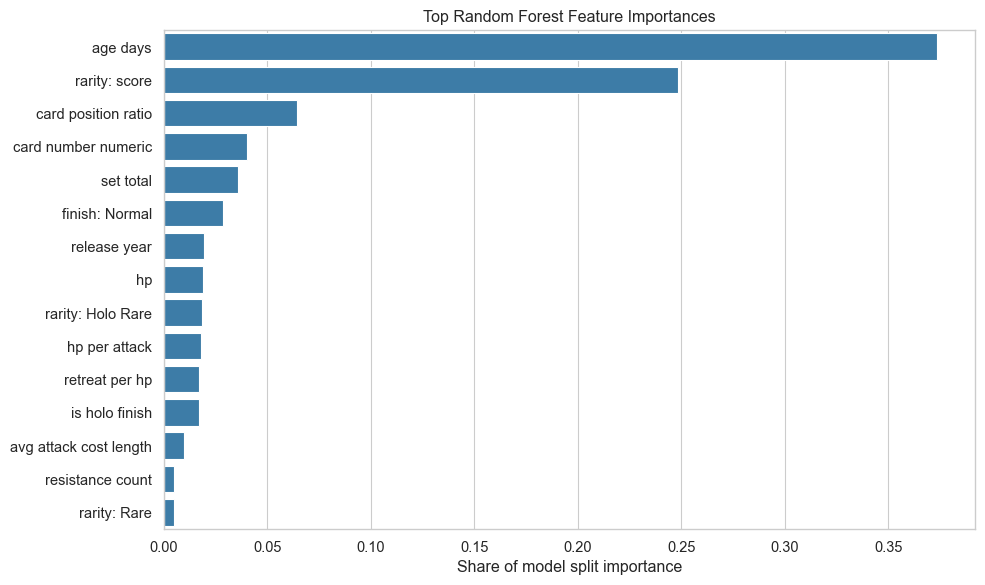

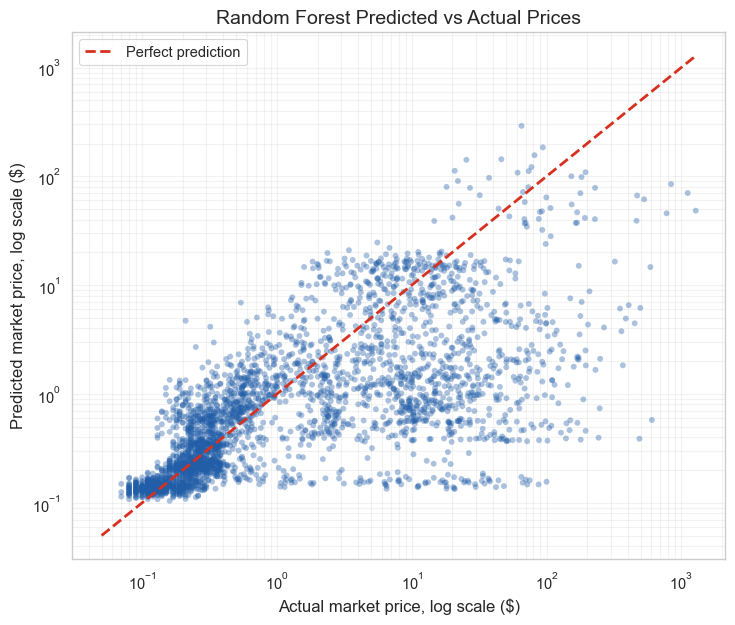

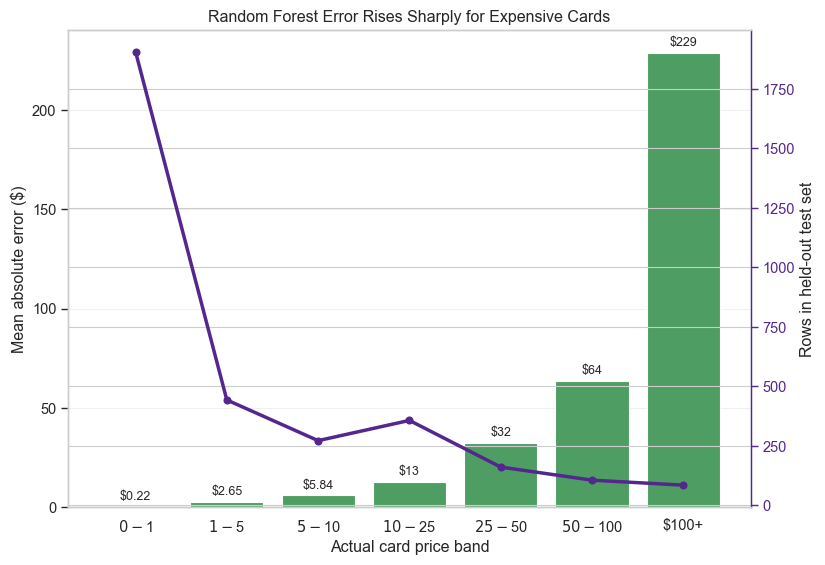

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path

REPORT_FIGURE_DIR = Path('reports/figures')
REPORT_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()
importances = rf_pipeline.named_steps['regressor'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

importance_df['Feature'] = importance_df['Feature'].str.replace('num__', '').str.replace('cat__', '')
importance_df['Feature'] = importance_df['Feature'].str.replace('finish_type_', 'finish: ')
importance_df['Feature'] = importance_df['Feature'].str.replace('rarity_', 'rarity: ')
importance_df['Feature'] = importance_df['Feature'].str.replace('primary_type_', 'type: ')
importance_df['Feature'] = importance_df['Feature'].str.replace('primary_subtype_', 'stage: ')
importance_df['Feature'] = importance_df['Feature'].str.replace('_', ' ')

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x='Importance', y='Feature', color='#2C7FB8')
plt.title('Top Random Forest Feature Importances')
plt.xlabel('Share of model split importance')
plt.ylabel('')
plt.tight_layout()
plt.savefig(REPORT_FIGURE_DIR / 'rf_feature_importance.png', dpi=220, bbox_inches='tight')
plt.show()

y_pred_log_rf = rf_pipeline.predict(X_test)

y_pred_actual_rf = np.maximum(np.expm1(y_pred_log_rf), 0)
predicted_vs_actual_df = pd.DataFrame({
    'actual': y_test_actual.to_numpy(),
    'predicted': y_pred_actual_rf
}).sample(min(len(y_test_actual), 3200), random_state=42)

plt.figure(figsize=(7.5, 6.4))
plt.scatter(predicted_vs_actual_df['actual'] + 0.05, predicted_vs_actual_df['predicted'] + 0.05, alpha=0.38, color='#225EA8', edgecolor='none', s=18)

max_val = max(predicted_vs_actual_df['actual'].max(), predicted_vs_actual_df['predicted'].max(), 1)
plt.plot([0.05, max_val], [0.05, max_val], color='#D7301F', linestyle='--', linewidth=2, label='Perfect prediction')

plt.xscale('log')
plt.yscale('log')
plt.title('Random Forest Predicted vs Actual Prices', fontsize=14)
plt.xlabel('Actual market price, log scale ($)', fontsize=12)
plt.ylabel('Predicted market price, log scale ($)', fontsize=12)
plt.legend()
plt.grid(True, which='both', alpha=0.25)
plt.tight_layout()
plt.savefig(REPORT_FIGURE_DIR / 'rf_predicted_vs_actual.png', dpi=220, bbox_inches='tight')
plt.show()

rf_error_summary = rf_price_band_results.copy()

fig, ax1 = plt.subplots(figsize=(8.4, 5.8))
bars = sns.barplot(data=rf_error_summary, x='Price Band', y='MAE', ax=ax1, color='#41AB5D')
ax1.set_title('Random Forest Error Rises Sharply for Expensive Cards')
ax1.set_xlabel('Actual card price band')
ax1.set_ylabel('Mean absolute error ($)')
ax1.bar_label(bars.containers[0], labels=[f'${value:,.0f}' if value >= 10 else f'${value:,.2f}' for value in rf_error_summary['MAE']], padding=3, fontsize=9)

ax2 = ax1.twinx()
ax2.plot(rf_error_summary['Price Band'], rf_error_summary['Card Count'], color='#54278F', marker='o', linewidth=2.5)
ax2.set_ylabel('Rows in held-out test set')
ax2.tick_params(axis='y', colors='#54278F')
ax2.spines['right'].set_color('#54278F')
ax1.grid(axis='y', alpha=0.28)
plt.tight_layout()
plt.savefig(REPORT_FIGURE_DIR / 'rf_price_band_error.png', dpi=220, bbox_inches='tight')
plt.show()

# Chart Anaylsis:
The first chart (Top 15 Feature Importances) ranks which variables the random forest relied on the most to make its price guesses. Based on our chart, the top 3 most important feature types are age_days which is how old the card is, finish_type_Holofoil, and finish_type_Normal, which are part of the card design. This confirms what we assumed earlier, the main driving point of card prices are rarity (card age) and card design, rather than the card's gameplay utility.

The second chart (Actual vs Predicted Card Prices) graphs the difference between the price predicted vs the actual price, and the red dotted line represents where the dots should be if the model was 100% accurate. In our chart we see majority of the dots clustered around the bottom left, which the model predicts decently well. As we move to the right towards the more expensive cards, the dots are low and below the red line which means the model is predicting low prices for expensive cards. This represents our huge RMSE gap from earlier.